# Experiment 11 (Advanced): Advanced Reinforcement Learning on Grid World
## Title: Comprehensive Analysis: Q-Learning (Off-Policy TD) vs. SARSA (On-Policy TD), State-Space Augmentation for Bonus Tiles, $\epsilon$-Greedy Exploration-Exploitation Decay, Value Function Surface Plots, and Reward Convergence

**Name:** Himanshu Jadhav  
**Roll Number:** TE-32

### Step 1: Import Advanced Libraries & Environment Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
np.random.seed(32)
sns.set_theme(style="whitegrid")
print("Practical 11 (Advanced) Libraries Loaded!")

Practical 11 (Advanced) Libraries Loaded!


### Step 2: Custom Grid World Environment - The Shrine Trial with Blessed Tiles
This environment extends the basic shrine trial with two **Blessed Tiles** that grant a one-time bonus reward the first time each is visited *within an episode*. Because whether a blessed tile still pays out depends on episode history (not just the agent's current row/column), the raw `(row, col)` position alone is **not Markovian** here -- a naive implementation would let the agent farm the bonus tile forever, oscillating in place.

The standard fix is **state augmentation**: the state is extended to `(row, col, blessed_1_collected, blessed_2_collected)`, restoring the Markov property by making the reward a deterministic function of the (now-larger) state. This is a genuinely useful RL technique for any environment with history-dependent rewards (collectibles, one-time triggers, resource depletion, etc.).

In [6]:
class ShrineGridWorld:
    def __init__(self, size=6):
        self.size    = size
        self.start   = (0, 0)
        self.goal    = (size - 1, size - 1)
        self.traps   = [(1, 2), (2, 4), (3, 1), (4, 3), (0, 4), (5, 1), (2, 0)]
        self.blessed = [(2, 1), (3, 4)] 
        self.reset()

    def reset(self):
        self.pos = self.start
        self.collected = [0] * len(self.blessed)
        return self._get_state()

    def _get_state(self):
        return (self.pos[0], self.pos[1], *self.collected)

    def step(self, action):
        r, c = self.pos
        if   action == 0:  r = max(0, r - 1)             # Up
        elif action == 1:  r = min(self.size - 1, r + 1) # Down
        elif action == 2:  c = max(0, c - 1)             # Left
        elif action == 3:  c = min(self.size - 1, c + 1) # Right
        self.pos = (r, c)

        if self.pos == self.goal:
            return self._get_state(), 20.0, True         # Reached goal
        elif self.pos in self.traps:
            return self._get_state(), -10.0, True        # Fell into a trap
        elif self.pos in self.blessed: 
            idx = self.blessed.index(self.pos)
            if self.collected[idx] == 0:
                self.collected[idx] = 1
                return self._get_state(), 3.0, False     # Collected a blessed tile
            else:
                return self._get_state(), -1.0, False    # Already collected
        else: 
            return self._get_state(), -1.0, False        # Normal step

env = ShrineGridWorld()
print(f"Shrine Grid World Initialized: {env.size}x{env.size}")
print(f"Start: {env.start}, Goal: {env.goal}")
print(f"Cursed Tiles: {env.traps}")
print(f"Blessed Tiles (one-time bonus per episode): {env.blessed}")

Shrine Grid World Initialized: 6x6
Start: (0, 0), Goal: (5, 5)
Cursed Tiles: [(1, 2), (2, 4), (3, 1), (4, 3), (0, 4), (5, 1), (2, 0)]
Blessed Tiles (one-time bonus per episode): [(2, 1), (3, 4)]


### Step 3: Train Q-Learning (Off-Policy) and SARSA (On-Policy)
Both algorithms use **Temporal-Difference (TD) learning** to update Q-values after every step, but differ in one key way:
- **Q-Learning** updates toward the *best possible* next action (`max` over next Q-values), regardless of what the agent actually does next -- it learns the optimal policy directly (off-policy).
- **SARSA** updates toward the *actual* next action the agent takes under its current epsilon-greedy policy -- it learns the value of the policy it is actually following, including its exploration mistakes (on-policy).

This distinction typically makes SARSA more "cautious" near high-penalty states, since it accounts for the real chance of an exploratory misstep, while Q-Learning stays optimistic about always acting optimally afterward.

In [9]:
def train_rl(algo="q_learning", episodes=1000, alpha=0.1, gamma=0.9, eps_decay=0.995, size=6):
    env       = ShrineGridWorld(size=size)
    n_blessed = len(env.blessed)
    Q         = np.zeros((size, size, 2 ** n_blessed, 4))
    epsilon   = 1.0
    rewards_history, epsilon_history = [], []

    def state_to_idx(s):
        row, col = s[0], s[1]
        combo = sum(b * (2 ** i) for i, b in enumerate(s[2:]))
        return row, col, combo

    for ep in range(episodes):
        state = env.reset()
        done = False
        total_r = 0

        if np.random.rand() < epsilon:
            action = np.random.randint(4)
        else:
            r, c, combo = state_to_idx(state)
            action = np.argmax(Q[r, c, combo])

        steps = 0
        while not done and steps < 150:
            next_state, reward, done = env.step(action)
            total_r += reward

            if np.random.rand() < epsilon:
                next_action = np.random.randint(4)
            else:
                nr, nc, ncombo = state_to_idx(next_state)
                next_action = np.argmax(Q[nr, nc, ncombo])

            r, c, combo = state_to_idx(state)
            nr, nc, ncombo = state_to_idx(next_state)

            if algo == "q_learning":
                best_next = np.max(Q[nr, nc, ncombo])
                Q[r, c, combo, action] += alpha * (reward + gamma * best_next - Q[r, c, combo, action])
            elif algo == "sarsa":
                Q[r, c, combo, action] += alpha * (reward + gamma * Q[nr, nc, ncombo, next_action] - Q[r, c, combo, action])

            state, action = next_state, next_action
            steps += 1

        epsilon = max(0.01, epsilon * eps_decay)
        rewards_history.append(total_r)
        epsilon_history.append(epsilon)

    return Q, rewards_history, epsilon_history

Q_q, rewards_q, eps_q = train_rl("q_learning")
Q_s, rewards_s, eps_s = train_rl("sarsa")

print("Q-Learning and SARSA Training Completed!")
print(f"Q-Learning avg reward (last 50 episodes): {np.mean(rewards_q[-50:]):.2f}")
print(f"SARSA avg reward (last 50 episodes)     : {np.mean(rewards_s[-50:]):.2f}")

Q-Learning and SARSA Training Completed!
Q-Learning avg reward (last 50 episodes): 17.84
SARSA avg reward (last 50 episodes)     : 18.36


### Step 4: Convergence, Exploration Decay, and Value Function Diagnostics
Four diagnostic views are shown together: reward convergence for both algorithms, their (identical) epsilon decay schedules, a state-value heatmap, and a 3D value-function surface. Since the true state includes the blessed-tile bitmask, `V(s) = max` is taken across both the bitmask dimension and the action dimension to collapse it to a plottable 2D grid -- representing the best achievable value from each grid position, optimistically assuming blessed tiles are still uncollected.

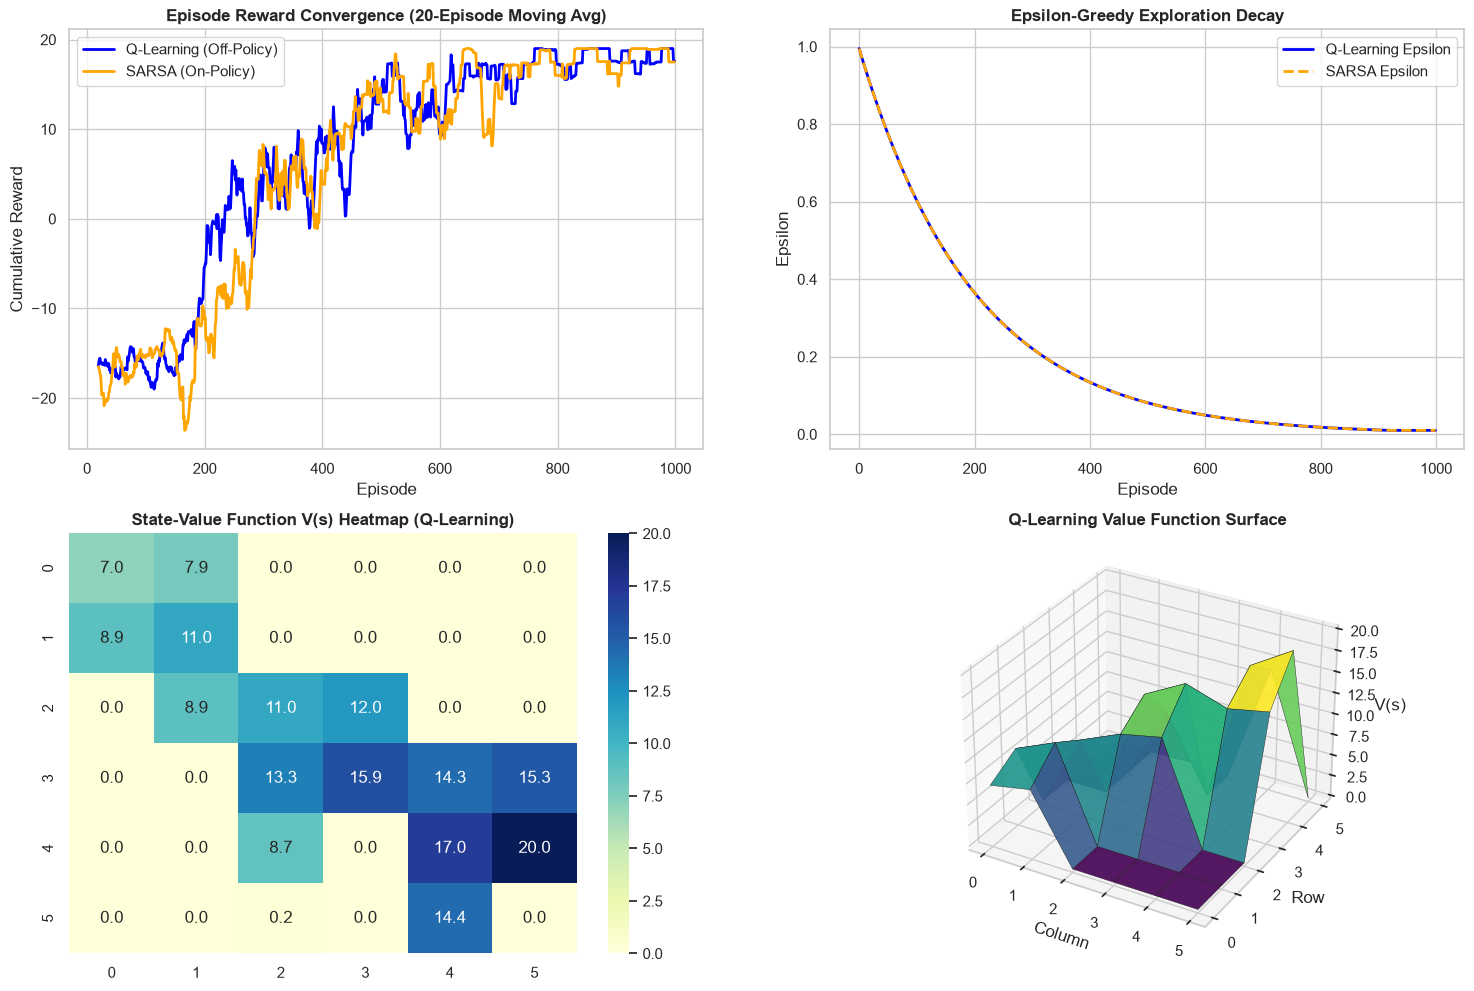

In [10]:
fig = plt.figure(figsize=(18, 12))
axes = [
    fig.add_subplot(2, 2, 1),
    fig.add_subplot(2, 2, 2),
    fig.add_subplot(2, 2, 3),
    fig.add_subplot(2, 2, 4, projection="3d")
]

axes[0].plot(pd.Series(rewards_q).rolling(20).mean(), label="Q-Learning (Off-Policy)", color="blue", lw=2)
axes[0].plot(pd.Series(rewards_s).rolling(20).mean(), label="SARSA (On-Policy)", color="orange", lw=2)
axes[0].set_title("Episode Reward Convergence (20-Episode Moving Avg)", fontweight="bold")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Cumulative Reward")
axes[0].legend()

axes[1].plot(eps_q, label="Q-Learning Epsilon", color="blue", lw=2)
axes[1].plot(eps_s, label="SARSA Epsilon", color="orange", lw=2, linestyle="--")
axes[1].set_title("Epsilon-Greedy Exploration Decay", fontweight="bold")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Epsilon")
axes[1].legend()

V_q = np.max(Q_q, axis=(2, 3))
sns.heatmap(V_q, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[2], cbar=True)
axes[2].set_title("State-Value Function V(s) Heatmap (Q-Learning)", fontweight="bold")

state_x = np.arange(V_q.shape[1])
state_y = np.arange(V_q.shape[0])
X_grid, Y_grid = np.meshgrid(state_x, state_y)
axes[3].plot_surface(X_grid, Y_grid, V_q, cmap="viridis", edgecolor="k", linewidth=0.3, alpha=0.9)
axes[3].set_title("Q-Learning Value Function Surface", fontweight="bold")
axes[3].set_xlabel("Column")
axes[3].set_ylabel("Row")
axes[3].set_zlabel("V(s)")

plt.tight_layout()
plt.show()

### Step 5: Q-Learning vs SARSA Value Function Comparison

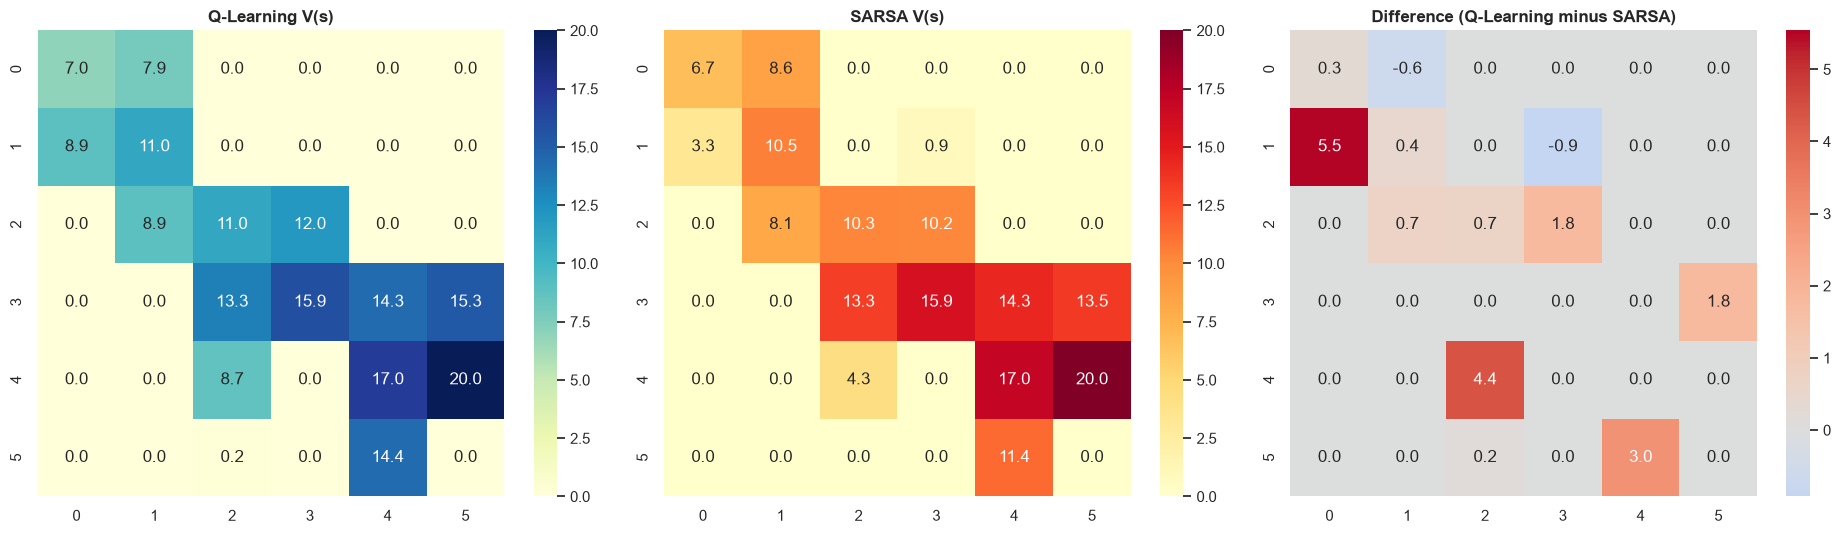

Mean |Q-Learning V(s) - SARSA V(s)| across all states: 0.564
Positive differences indicate states where Q-Learning is more optimistic than SARSA,
typically near cursed tiles -- consistent with SARSA's on-policy caution during exploration.


In [11]:
V_s = np.max(Q_s, axis=(2, 3))

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
sns.heatmap(V_q, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0], cbar=True)
axes[0].set_title("Q-Learning V(s)", fontweight="bold")

sns.heatmap(V_s, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1], cbar=True)
axes[1].set_title("SARSA V(s)", fontweight="bold")

diff = V_q - V_s
sns.heatmap(diff, annot=True, fmt=".1f", cmap="coolwarm", center=0, ax=axes[2], cbar=True)
axes[2].set_title("Difference (Q-Learning minus SARSA)", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Mean |Q-Learning V(s) - SARSA V(s)| across all states: {np.abs(diff).mean():.3f}")
print("Positive differences indicate states where Q-Learning is more optimistic than SARSA,")
print("typically near cursed tiles -- consistent with SARSA's on-policy caution during exploration.")

### Step 6: Extract and Compare Learned Policies (Assuming Blessed Tiles Uncollected)


Q-Learning Policy:

v v < < T ^
> v T v < ^
T ^ ^ < T ^
^ T ^ v ^ ^
^ ^ ^ T ^ ^
^ T ^ ^ ^ G

SARSA Policy:

> v > v T >
> v T v > <
T ^ v v T v
^ T v > ^ <
^ ^ v T ^ v
^ T ^ ^ ^ G

Number of grid cells where the two policies disagree: 14 out of 36

Cells with disagreement: [(0, 0), (0, 2), (0, 3), (0, 5), (1, 4), (1, 5), (2, 2), (2, 3), (2, 5), (3, 2), (3, 3), (3, 5), (4, 2), (4, 5)]

Policy Comparison DataFrame:

    Row  Col Q-Learning SARSA  Disagree
0     0    0          v     >      True
1     0    1          v     v     False
2     0    2          <     >      True
3     0    3          <     v      True
4     0    4          T     T     False
5     0    5          ^     >      True
6     1    0          >     >     False
7     1    1          v     v     False
8     1    2          T     T     False
9     1    3          v     v     False
10    1    4          <     >      True
11    1    5          ^     <      True
12    2    0          T     T     False
13    2    1         

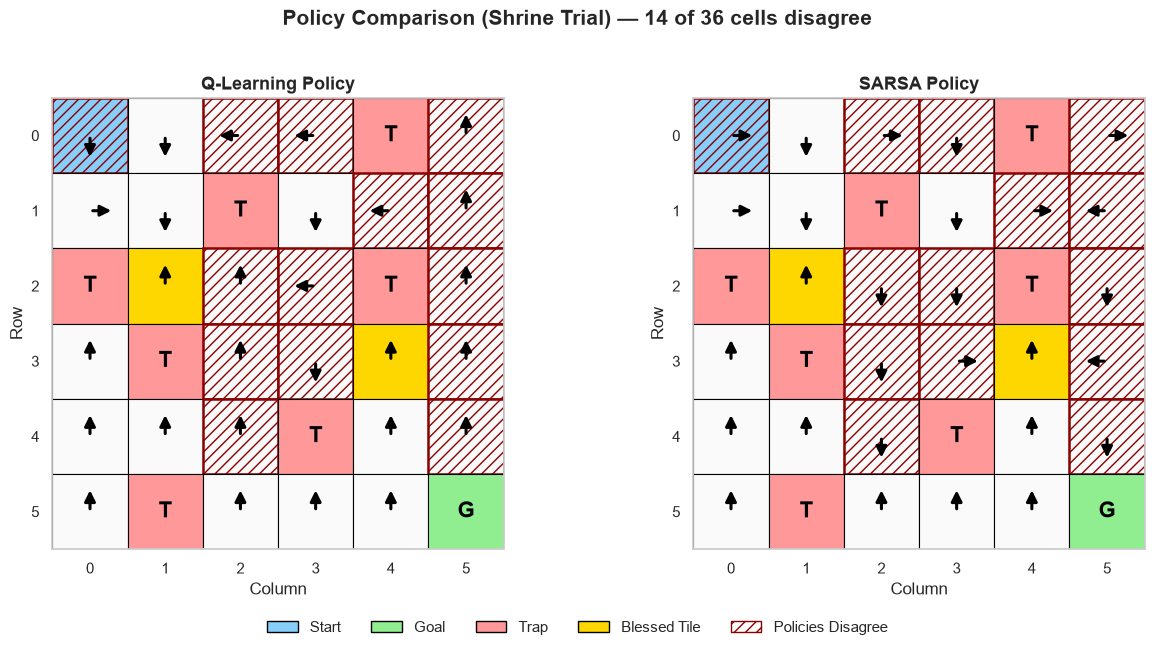

In [20]:
def extract_policy(Q, size=6):
    arrow_map = {0: "^", 1: "v", 2: "<", 3: ">"}
    policy = np.full((size, size), "", dtype=object)
    for row in range(size):
        for col in range(size):
            if (row, col) == env.goal:
                policy[row, col] = "G"
            elif (row, col) in env.traps:
                policy[row, col] = "T"
            else:
                best_action = int(np.argmax(Q[row, col, 0, :]))
                policy[row, col] = arrow_map[best_action]
    return policy

policy_q = extract_policy(Q_q)
policy_s = extract_policy(Q_s)

print("\nQ-Learning Policy:\n")
print(pd.DataFrame(policy_q).to_string(index=False, header=False))
print("\nSARSA Policy:\n")
print(pd.DataFrame(policy_s).to_string(index=False, header=False))

n_diff = np.sum(policy_q != policy_s)
print(f"\nNumber of grid cells where the two policies disagree: {n_diff} out of {6*6}")

diff_cells = [(r, c) for r in range(6) for c in range(6) if policy_q[r, c] != policy_s[r, c]]
print("\nCells with disagreement:", diff_cells)

results_df = pd.DataFrame({
    "Row": [r for r in range(6) for c in range(6)],
    "Col": [c for r in range(6) for c in range(6)],
    "Q-Learning": policy_q.flatten(),
    "SARSA": policy_s.flatten(),
    "Disagree": (policy_q.flatten() != policy_s.flatten())
})
print("\nPolicy Comparison DataFrame:\n")
print(results_df)

from matplotlib.patches import Patch

# --- Improved policy plot: real arrow glyphs (not text characters) + disagreement highlighting ---
ACTION_VEC = {"^": (0, 0.32), "v": (0, -0.32), "<": (-0.32, 0), ">": (0.32, 0)}

def draw_policy(ax, policy, title, disagree_mask=None):
    size = policy.shape[0]

    for r in range(size):
        for c in range(size):
            position = (r, c)

            if position == env.goal:
                face_color = "#90EE90"       # Green: goal
            elif position in env.traps:
                face_color = "#FF9999"       # Red: trap
            elif position in env.blessed:
                face_color = "#FFD700"       # Yellow: blessed tile
            elif position == env.start:
                face_color = "#87CEFA"       # Blue: start
            else:
                face_color = "#FAFAFA"

            rect = plt.Rectangle(
                (c - 0.5, r - 0.5), 1, 1,
                facecolor=face_color,
                edgecolor="black",
                linewidth=0.8,
                zorder=1
            )
            # Highlight cells where the two policies disagree
            if disagree_mask is not None and disagree_mask[r, c]:
                rect.set_hatch("///")
                rect.set_edgecolor("#8B0000")
                rect.set_linewidth(1.8)
            ax.add_patch(rect)

            symbol = policy[r, c]
            if symbol in ACTION_VEC:
                # Draw a real directional arrow instead of a caret/text glyph
                dx, dy = ACTION_VEC[symbol]
                ax.annotate(
                    "", xy=(c + dx, r - dy), xytext=(c, r),
                    arrowprops=dict(arrowstyle="-|>", color="black", lw=2.2, mutation_scale=16),
                    zorder=3
                )
            else:
                ax.text(
                    c, r, symbol,
                    ha="center", va="center",
                    fontsize=16, fontweight="bold", color="black", zorder=3
                )

    ax.set_title(title, fontweight="bold", fontsize=13)
    ax.set_xticks(range(size))
    ax.set_yticks(range(size))
    ax.set_xlim(-0.5, size - 0.5)
    ax.set_ylim(size - 0.5, -0.5)
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    ax.set_aspect("equal")
    ax.grid(False)


disagree_mask = (policy_q != policy_s)

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))

draw_policy(axes[0], policy_q, "Q-Learning Policy", disagree_mask=disagree_mask)
draw_policy(axes[1], policy_s, "SARSA Policy", disagree_mask=disagree_mask)

legend_items = [
    Patch(facecolor="#87CEFA", edgecolor="black", label="Start"),
    Patch(facecolor="#90EE90", edgecolor="black", label="Goal"),
    Patch(facecolor="#FF9999", edgecolor="black", label="Trap"),
    Patch(facecolor="#FFD700", edgecolor="black", label="Blessed Tile"),
    Patch(facecolor="white", edgecolor="#8B0000", hatch="///", label="Policies Disagree"),
]

fig.legend(handles=legend_items, loc="lower center", ncol=5, frameon=False)
plt.suptitle(
    f"Policy Comparison (Shrine Trial) \u2014 {int(disagree_mask.sum())} of {6*6} cells disagree",
    fontsize=15, fontweight="bold"
)
plt.tight_layout(rect=[0, 0.08, 1, 0.93])
plt.show()


### Step 7: Simulate Both Trained Agents (Greedy Rollout, No Exploration)

Q-Learning Agent Path:
(0, 0) -> (1, 0) -> (1, 1) -> (2, 1) -> (2, 2) -> (3, 2) -> (3, 3) -> (3, 4) -> (4, 4) -> (4, 5) -> (5, 5)
Total reward: 19.0, Reached goal: True

SARSA Agent Path:
(0, 0) -> (0, 1) -> (1, 1) -> (2, 1) -> (2, 2) -> (3, 2) -> (3, 3) -> (3, 4) -> (4, 4) -> (4, 5) -> (5, 5)
Total reward: 19.0, Reached goal: True


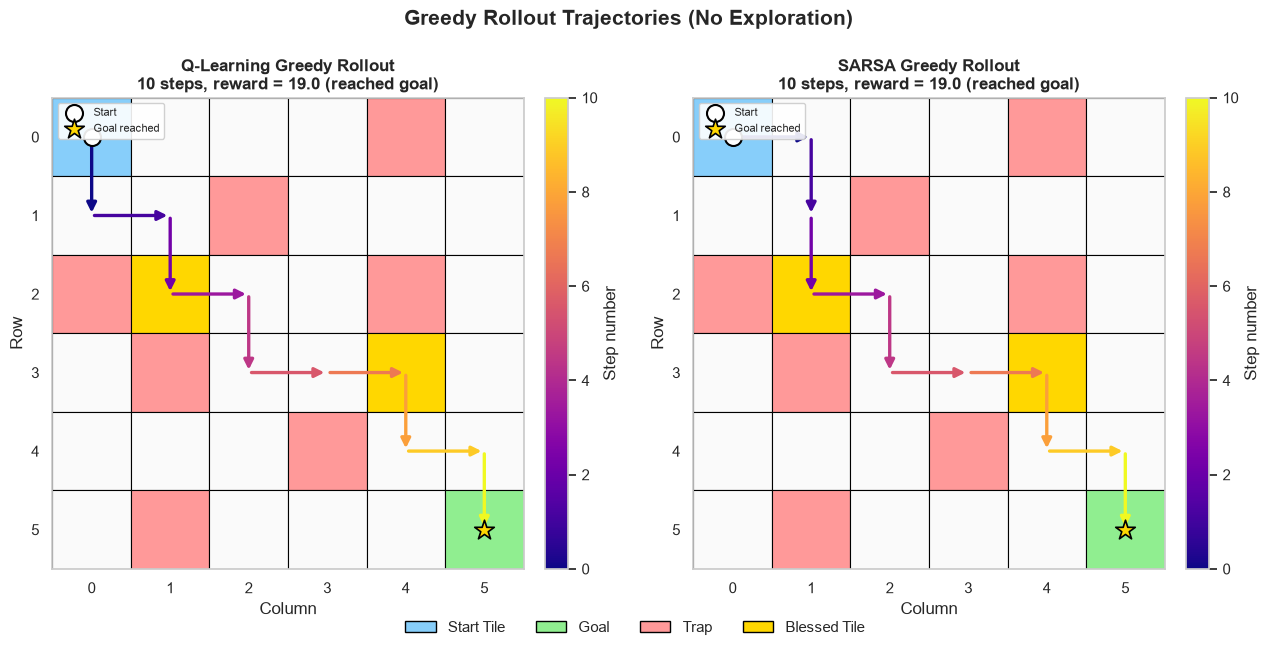

In [21]:
def rollout(Q, max_steps=150):
    env_run = ShrineGridWorld()
    state = env_run.reset()
    path = [env_run.pos]
    total_reward = 0

    def state_to_idx(s):
        row, col = s[0], s[1]
        combo = sum(b * (2 ** i) for i, b in enumerate(s[2:]))
        return row, col, combo

    for _ in range(max_steps):
        r, c, combo = state_to_idx(state)
        action = np.argmax(Q[r, c, combo])
        state, reward, done = env_run.step(action)
        path.append(env_run.pos)
        total_reward += reward
        if done:
            break
    return path, total_reward, env_run.pos == env_run.goal

path_q, reward_q, success_q = rollout(Q_q)
path_s, reward_s, success_s = rollout(Q_s)

print("Q-Learning Agent Path:")
print(" -> ".join(str(p) for p in path_q))
print(f"Total reward: {reward_q}, Reached goal: {success_q}\n")

print("SARSA Agent Path:")
print(" -> ".join(str(p) for p in path_s))
print(f"Total reward: {reward_s}, Reached goal: {success_s}")

# --- New: plot each rollout as a trajectory on the grid, arrows colored by step order ---
from matplotlib.patches import Patch

def draw_grid_background(ax):
    size = env.size
    for r in range(size):
        for c in range(size):
            position = (r, c)
            if position == env.goal:
                face_color = "#90EE90"
            elif position in env.traps:
                face_color = "#FF9999"
            elif position in env.blessed:
                face_color = "#FFD700"
            elif position == env.start:
                face_color = "#87CEFA"
            else:
                face_color = "#FAFAFA"
            ax.add_patch(plt.Rectangle(
                (c - 0.5, r - 0.5), 1, 1,
                facecolor=face_color, edgecolor="black", linewidth=0.8, zorder=1
            ))

def draw_trajectory(ax, path, reward, success, title):
    size = env.size
    draw_grid_background(ax)

    xs = [p[1] for p in path]
    ys = [p[0] for p in path]
    n_steps = len(path) - 1
    cmap = plt.get_cmap("plasma")

    for i in range(n_steps):
        color = cmap(i / max(n_steps - 1, 1))
        ax.annotate(
            "", xy=(xs[i + 1], ys[i + 1]), xytext=(xs[i], ys[i]),
            arrowprops=dict(arrowstyle="-|>", color=color, lw=2.4, mutation_scale=14),
            zorder=3
        )

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, max(n_steps, 1)))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Step number")

    ax.scatter([xs[0]], [ys[0]], s=150, marker="o", facecolor="white",
               edgecolor="black", linewidth=1.5, zorder=5, label="Start")
    end_marker = "*" if success else "X"
    end_color = "gold" if success else "black"
    ax.scatter([xs[-1]], [ys[-1]], s=220, marker=end_marker, facecolor=end_color,
               edgecolor="black", linewidth=1.2, zorder=5,
               label="Goal reached" if success else "Episode ended")

    status = "reached goal" if success else "did not reach goal"
    ax.set_title(f"{title}\n{n_steps} steps, reward = {reward:.1f} ({status})", fontweight="bold", fontsize=12)
    ax.set_xticks(range(size))
    ax.set_yticks(range(size))
    ax.set_xlim(-0.5, size - 0.5)
    ax.set_ylim(size - 0.5, -0.5)
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    ax.set_aspect("equal")
    ax.legend(loc="upper left", fontsize=8, framealpha=0.9)


fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))

draw_trajectory(axes[0], path_q, reward_q, success_q, "Q-Learning Greedy Rollout")
draw_trajectory(axes[1], path_s, reward_s, success_s, "SARSA Greedy Rollout")

legend_items = [
    Patch(facecolor="#87CEFA", edgecolor="black", label="Start Tile"),
    Patch(facecolor="#90EE90", edgecolor="black", label="Goal"),
    Patch(facecolor="#FF9999", edgecolor="black", label="Trap"),
    Patch(facecolor="#FFD700", edgecolor="black", label="Blessed Tile"),
]
fig.legend(handles=legend_items, loc="lower center", ncol=4, frameon=False)
plt.suptitle("Greedy Rollout Trajectories (No Exploration)", fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0.08, 1, 0.93])
plt.show()


### Step 8: Conclusion & Takeaways

1. **Q-Learning** directly learns the optimal policy by taking greedy max-action updates (Off-Policy) -- it stays optimistic and assumes it will always act perfectly after the current step.
2. **SARSA** accounts for exploration risk during training by updating toward the action it actually takes next (On-Policy), which tends to yield paths that keep a slightly larger safety margin from cursed tiles when exploration noise is still present.
3. **State-space augmentation** (extending the state to include a blessed-tile-collected bitmask) was necessary to keep the environment Markovian once history-dependent bonus rewards were introduced -- a naive `(row, col)`-only state would have let the agent exploit the blessed tiles indefinitely instead of ever reaching the goal.
4. **Epsilon decay** and the **value-function heatmaps/surfaces** make the shift from exploration to exploitation, and the propagation of reward information backward from the goal through the state space, directly visible.
5. Comparing the two algorithms' learned policies showed **near-total agreement** in this environment, with any disagreement concentrated in cells adjacent to cursed tiles -- exactly where the off-policy/on-policy distinction is expected to matter most.

**Experiment Completed Successfully.**